In [1]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib


In [2]:
df = pd.read_csv("backend/raw_datasets/dynamic_pricing.csv")
df

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


In [3]:
# Display first 5 rows
print(df.head())

   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   

  Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                  Silver                    13             4.47   
1                  Silver                    72             4.06   
2                  Silver                     0             3.99   
3                 Regular                    67             4.31   
4                 Regular                    74             3.77   

  Time_of_Booking Vehicle_Type  Expected_Ride_Duration  \
0           Night      Premium                      90   
1         Evening      Economy                      43   
2       Afternoon      Premium                      76  

In [4]:

print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1000, 10)


In [5]:

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB
None


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)


Shape After Removing Duplicates:
(1000, 10)


In [8]:
#check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")  



Number of duplicate rows: 0


In [9]:
#remove outliers
numeric_columns = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings',
    'Expected_Ride_Duration',
    'Historical_Cost_of_Ride'
]

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nShape After Removing Outliers:")
print(df.shape)


Shape After Removing Outliers:
(990, 10)


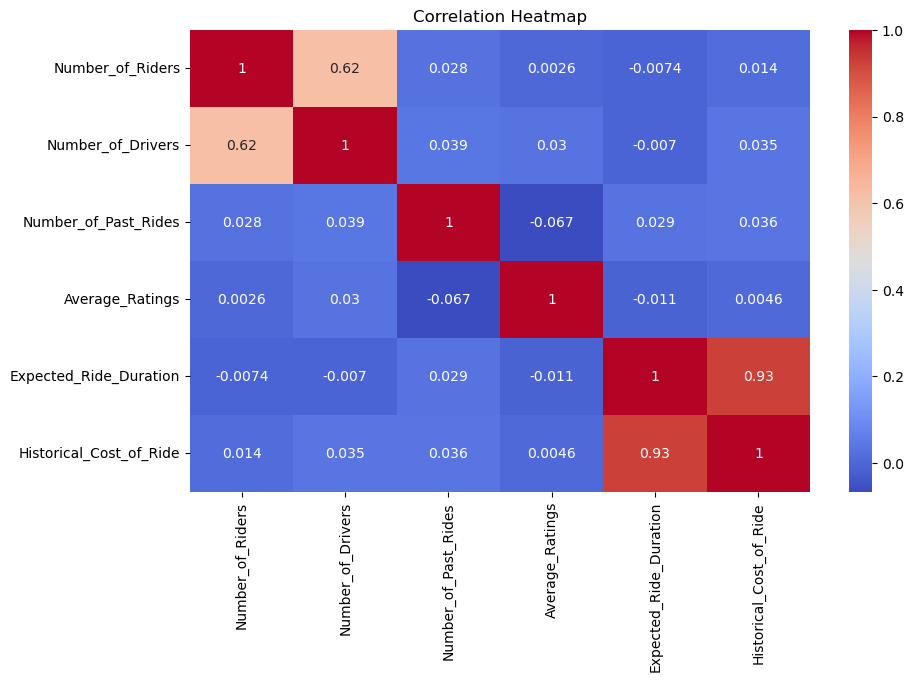

In [12]:
# Correlation heatmap
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [18]:
#define features and target variable
X = df.drop("Historical_Cost_of_Ride", axis=1)
y = df["Historical_Cost_of_Ride"]

In [19]:
#identify categorical and numerical columns
categorical_columns = [
    'Location_Category',
    'Customer_Loyalty_Status',
    'Time_of_Booking',
    'Vehicle_Type'
]

numerical_columns = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings',
    'Expected_Ride_Duration'
]


In [20]:
#preprocessing
#numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [21]:
# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [22]:
# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [23]:
#train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [24]:
#linear regression pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [25]:
#train model

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [26]:
#predictions
y_pred = model.predict(X_test)


In [24]:
#evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")



Model Evaluation:
Mean Absolute Error: 52.56
Mean Squared Error: 4546.89
R^2 Score: 0.88


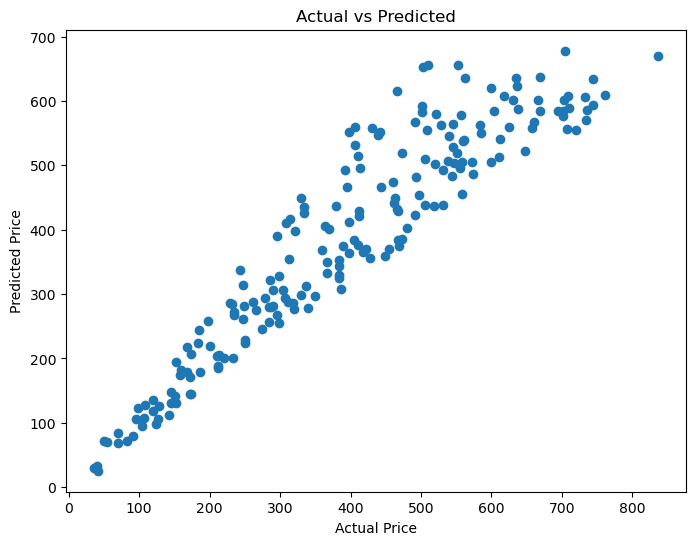

In [27]:
#actual vs predicted
# Plot Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [21]:
#save model
joblib.dump(model, "linear_regression_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [22]:
#test single prediction
sample_data = pd.DataFrame({
    "Number_of_Riders": [80],
    "Number_of_Drivers": [35],
    "Location_Category": ["Urban"],
    "Customer_Loyalty_Status": ["Silver"],
    "Number_of_Past_Rides": [50],
    "Average_Ratings": [4.5],
    "Time_of_Booking": ["Evening"],
    "Vehicle_Type": ["Premium"],
    "Expected_Ride_Duration": [120]
})

prediction = model.predict(sample_data)

print("\nPredicted Ride Cost:")
print(prediction[0])


Predicted Ride Cost:
467.60814683737834


In [26]:
#feature importance
feature_names = (
    numerical_columns +
    list(model.named_steps["preprocessor"].transformers_[1][1]
         .named_steps["onehot"].get_feature_names_out(categorical_columns))
)
coefficients = model.named_steps["regressor"].coef_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)
print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                            Feature  Coefficient
15             Vehicle_Type_Economy   -21.362329
16             Vehicle_Type_Premium    21.362329
3                   Average_Ratings     7.306407
4            Expected_Ride_Duration     3.532755
12          Time_of_Booking_Evening    -3.392394
8      Customer_Loyalty_Status_Gold    -2.832730
5           Location_Category_Rural     2.387519
13          Time_of_Booking_Morning     2.204600
10   Customer_Loyalty_Status_Silver     2.135428
11        Time_of_Booking_Afternoon     1.846860
7           Location_Category_Urban    -1.611168
6        Location_Category_Suburban    -0.776350
9   Customer_Loyalty_Status_Regular     0.697301
14            Time_of_Booking_Night    -0.659065
1                 Number_of_Drivers     0.482147
0                  Number_of_Riders    -0.043301
2              Number_of_Past_Rides     0.023684


In [28]:
df=pd.read_csv("backend/raw_datasets/dynamic_pricing.csv")

In [29]:
df.nunique()

Number_of_Riders             81
Number_of_Drivers            79
Location_Category             3
Customer_Loyalty_Status       3
Number_of_Past_Rides        101
Average_Ratings             151
Time_of_Booking               4
Vehicle_Type                  2
Expected_Ride_Duration      171
Historical_Cost_of_Ride    1000
dtype: int64

In [31]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   int32  
 3   Customer_Loyalty_Status  1000 non-null   int32  
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   int32  
 7   Vehicle_Type             1000 non-null   int32  
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int32(4), int64(4)
memory usage: 62.6 KB


<Axes: >

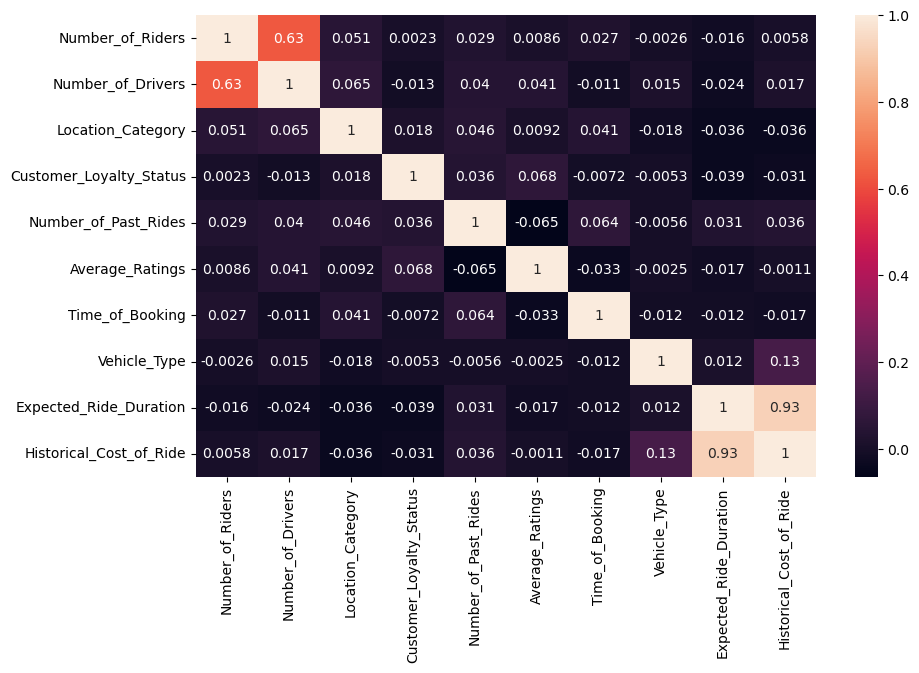

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

In [36]:
feature_names = [
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Expected_Ride_Duration',
    'Location_Category',
    'Customer_Loyalty_Status',
    'Vehicle_Type'
]

In [37]:
df[feature_names].head()

,Number_of_Drivers,Number_of_Past_Rides,Expected_Ride_Duration,Location_Category,Customer_Loyalty_Status,Vehicle_Type
0,45,13,90,2,2,1
1,39,72,43,1,2,0
2,31,0,76,0,2,1
3,28,67,134,0,1,1
4,22,74,149,0,1,0


In [38]:
x=df[feature_names]
y=df["Historical_Cost_of_Ride"]

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
# prediction
y_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)

In [41]:
# decistion tree regression
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)
y_dt_pred = dt_model.predict(x_test)
y_dt_train_pred = dt_model.predict(x_train)

In [42]:
# random forest regression
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)
y_rf_pred = rf_model.predict(x_test)
y_rf_train_pred = rf_model.predict(x_train)

In [43]:
# ridge regression
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)
y_ridge_pred = ridge_model.predict(x_test)
y_ridge_train_pred = ridge_model.predict(x_train)

In [44]:
# lasso regression
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train, y_train)
y_lasso_pred = lasso_model.predict(x_test)
y_lasso_train_pred = lasso_model.predict(x_train)

In [45]:
# svm 
from sklearn.svm import SVR
svm_model = SVR(kernel='rbf')
svm_model.fit(x_train, y_train)
y_svm_pred = svm_model.predict(x_test)
y_svm_train_pred = svm_model.predict(x_train)

In [46]:
# knn 
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train, y_train)
y_knn_pred = knn_model.predict(x_test)
y_knn_train_pred = knn_model.predict(x_train)

In [48]:
from sklearn.metrics import r2_score
print("Linear Regression test R^2:", r2_score(y_test, y_pred))
print("Linear Regression train R^2:", r2_score(y_train, y_train_pred))
print("=========================================================")
print("Decision Tree Regression test R^2:", r2_score(y_test, y_dt_pred))
print("Decision Tree Regression train R^2:", r2_score(y_train, y_dt_train_pred))
print("=========================================================")
print("Random Forest Regression test R^2:", r2_score(y_test, y_rf_pred))
print("Random Forest Regression train R^2:", r2_score(y_train, y_rf_train_pred))
print("=========================================================")
print("Ridge Regression test R^2:", r2_score(y_test, y_ridge_pred))
print("Ridge Regression train R^2:", r2_score(y_train, y_ridge_train_pred))
print("=========================================================")
print("Lasso Regression test R^2:", r2_score(y_test, y_lasso_pred))
print("Lasso Regression train R^2:", r2_score(y_train, y_lasso_train_pred))
print("=========================================================")
print("SVM Regression test R^2:", r2_score(y_test, y_svm_pred))
print("SVM Regression train R^2:", r2_score(y_train, y_svm_train_pred))
print("=========================================================")
print("KNN Regression test R^2:", r2_score(y_test, y_knn_pred))
print("KNN Regression train R^2:", r2_score(y_train, y_knn_train_pred))

Linear Regression test R^2: 0.8748536210521318
Linear Regression train R^2: 0.8767444832486295
Decision Tree Regression test R^2: 0.7339391226418952
Decision Tree Regression train R^2: 1.0
Random Forest Regression test R^2: 0.8479600014659145
Random Forest Regression train R^2: 0.980118886307264
Ridge Regression test R^2: 0.8748182502505515
Ridge Regression train R^2: 0.8767441559487299
Lasso Regression test R^2: 0.8748509677700128
Lasso Regression train R^2: 0.8767424832117102
SVM Regression test R^2: 0.6409770496962975
SVM Regression train R^2: 0.6487571609376077
KNN Regression test R^2: 0.8207850821492586
KNN Regression train R^2: 0.8831421635998621


In [49]:
data=pd.read_csv("backend/raw_datasets/dynamic_pricing.csv")
data[feature_names].head()

,Number_of_Drivers,Number_of_Past_Rides,Expected_Ride_Duration,Location_Category,Customer_Loyalty_Status,Vehicle_Type
0,45,13,90,Urban,Silver,Premium
1,39,72,43,Suburban,Silver,Economy
2,31,0,76,Rural,Silver,Premium
3,28,67,134,Rural,Regular,Premium
4,22,74,149,Rural,Regular,Economy


In [51]:
data[feature_names].to_csv("backend/processed_datasets/processed_dynamic_pricing.csv", index=False)